In [1]:

# a- Para una sola partícula de espín 1/2, el estado cuántico el estado cuántico se describe en un espacio de Hilbert de dimensión 2, con los estados base |↑> y |↓>.
# Por lo tanto, dado que tenermos N particulas independientes de dos dimenciones en el espacio de Hilbert, la dimension total del sistema es dim(H_total) = 2 * 2 * ... * 2 = 2^N.
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import time
from scipy.optimize import curve_fit

# Definición de primitivas (matrices de Pauli y estado base)
I = np.array([[1, 0], [0, 1]], dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
ket_down = np.array([0, 1], dtype=complex) # Estado |↓>

In [2]:
# b- Dado que el Hamiltoniano del modelo de Ising está definido  mediante el producto tensorial recursivo de las matrices de pauli
#    debemos definir una función que contruya el operador global (sigma alpha j) a partir de un operador local (sigma_x o sigma_z)
#    Para ello se usa el producto de Kronecker de numpy (producto tensorial) para asi expandir el operdor local al espacio de Hilbert 
#    completo de dimensión 2^N.

def armar_operador(op_local, j, N):
    op_global = 1
    for k in range(N):
        if k == j:
            op_global = np.kron(op_global, op_local)
        else:
            op_global = np.kron(op_global, I)
    return op_global

# Ya con esta función podemos contruir el Hamiltoniano del modelo de Ising, mediante la definición dada

def armar_hamiltoniano(N, J, B):
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)
    
    # Interacción a primeros vecinos (J)
    for i in range(N - 1):
        sx_i = armar_operador(sigma_x, i, N)
        sx_next = armar_operador(sigma_x, i + 1, N)
        H += J * np.dot(sx_i, sx_next)
        
    # Campo magnético transversal (B)
    for i in range(N):
        sz_i = armar_operador(sigma_z, i, N)
        H += B * sz_i
        
    return H

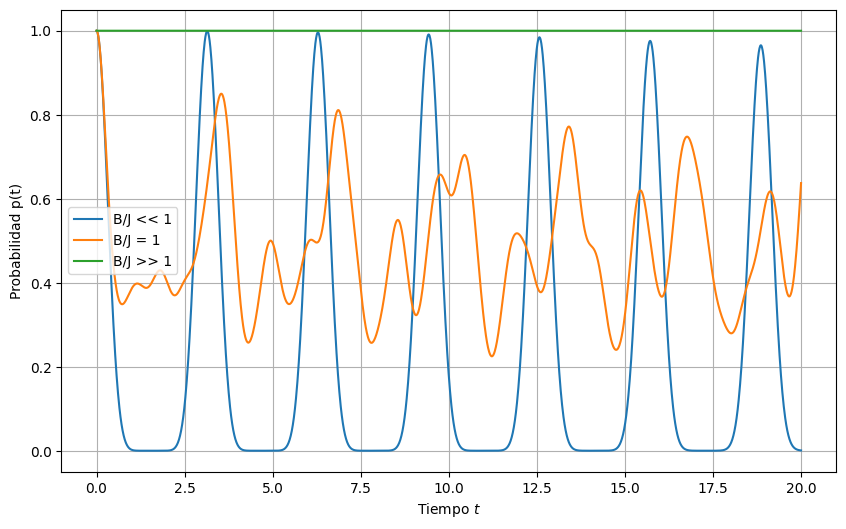

In [3]:
#c- Primero de forma similar usando np.kron contruimos el estado inicial del sistema. Luego simulando para N=6 (por ejemplo)
#   y calculando el operador U(t) mediante la función expm de scipy, se puede iterar la evolución temporal del estado psi(t) 
#   y calcular la probabilidad p(t) = |<Psi(0)|Psi(t)>|^2 para cada paso de tiempo.

def estado_inicial(N):
    psi = ket_down
    for _ in range(N - 1):
        psi = np.kron(psi, ket_down)
    return psi

N_sim = 6
t_max = 20
dt = 0.01
steps = int(t_max / dt)
t_array = np.linspace(0, t_max, steps)

# Cremos este array ejemplificando los 3 casos pedidos, para meter todo en el mismo ciclo for y graficar todo junto.
casos = [(1.0, 0.01), (1.0, 1.0), (0.01, 1.0)]
etiquetas = ["B/J << 1", "B/J = 1", "B/J >> 1"]

plt.figure(figsize=(10, 6))

for (J, B), label in zip(casos, etiquetas):
    H = armar_hamiltoniano(N_sim, J, B)
    U = expm(-1j * H * dt)
    
    psi_0 = estado_inicial(N_sim)
    psi_t = psi_0.copy()
    
    p_t = np.zeros(steps)
    
    for k in range(steps):
        p_t[k] = np.abs(np.vdot(psi_0, psi_t))**2
        psi_t = np.dot(U, psi_t) # Calculamos psi(t + dt) a partir de psi(t) y el operador de evolución U
        
    plt.plot(t_array, p_t, label=label)

plt.xlabel("Tiempo $t$")
plt.ylabel("Probabilidad p(t)")
plt.legend()
plt.grid(True)
plt.show()

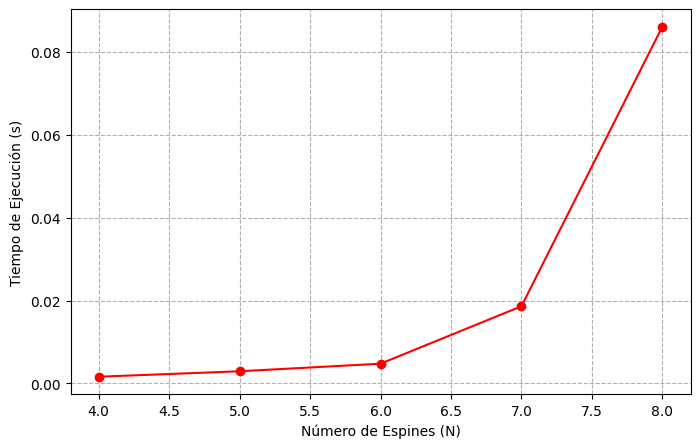

In [4]:

# d y e- Para medir el tiempo de ejecución de la diagonalización exacta del Hamiltoniano, se puede usar la función time.perf_counter() antes y después de la construcción 
#        y diagonalización del Hamiltoniano para cada valor de N. Luego se promedia el tiempo de ejecución sobre varias realizaciones para obtener una estimación más precisa. 
#        Finalmente, se grafica el tiempo de ejecución en función de N.

N_vals = np.array([4, 5, 6, 7, 8])
tiempos_ejecucion = []
realizaciones = 50 

J, B = 1.0, 1.0 #usaremos el caso mas simple para emdir el tiempo de ejecución

for N in N_vals:
    t_sum = 0
    for _ in range(realizaciones):
        start_time = time.perf_counter()
        H_n = armar_hamiltoniano(N, J, B)
        eigvals, eigvecs = np.linalg.eigh(H_n) #np.linalg.eigh funciona para matrices hermíticas, lo cual es el caso de nuestro Hamiltoniano y esta devuelve los autovalores y autovectores ordenados.
        end_time = time.perf_counter()
        t_sum += (end_time - start_time)
        
    tiempos_ejecucion.append(t_sum / realizaciones)

plt.figure(figsize=(8, 5))
plt.plot(N_vals, tiempos_ejecucion, marker='o', linestyle='-', color='r')
plt.xlabel("Número de Espines (N)")
plt.ylabel("Tiempo de Ejecución (s)")
plt.grid(True, which="both", ls="--")
plt.show()

In [10]:
# f y g- Para estimar el tiempo de ejecución para N=20, 50 y 100, se asume un modelo de escalamiento exponencial T(N) = A * 2**(3*N). ya que teoricamente diagonalizar matrices tiene un costo operacional de O(n**3) y en este caso
#        n = 2**N, por lo tanto T(N) = A * (2**N)**3 = A * 8**N. Se determina A empíricamente a partir
#        de las mediciones de los incisos anteriores.

# Calculamos la constante A para cada medición y promediamos
A_vals = tiempos_ejecucion / (8.0**N_vals)
A_est = np.mean(A_vals)

def estimar_N_teorico(N):
    return A_est * (8.0**N)

N_targets = [20, 50, 100]
edad_universo_s = 4.3e17 

for N_t in N_targets:
    t_est = estimar_N_teorico(N_t)
    print(f"Para N ={N_t:3d}, Tiempo estimado de: {t_est:.2e} segundos")
    if t_est > edad_universo_s:
        factor = t_est / edad_universo_s
        print(f"             Esto equivale a {factor:.2e} veces la edad del Universo.")

Para N = 20, Tiempo estimado de: 1.20e+11 segundos
Para N = 50, Tiempo estimado de: 1.48e+38 segundos
             Esto equivale a 3.44e+20 veces la edad del Universo.
Para N =100, Tiempo estimado de: 2.11e+83 segundos
             Esto equivale a 4.91e+65 veces la edad del Universo.
